In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import os, json, random
from scipy import optimize
from scipy.optimize import curve_fit
from numpy import pi, cos, sin, log
import pandas as pd
#from qutip import * 

In [2]:
def ABCD_HL(zhi, f, length, veff):
    ABCD_matrix = np.matrix([[cos(2*pi*f*length/veff), 1j*zhi*sin(2*pi*f*length/veff)], 
                             [1j/zhi*sin(2*pi*f*length/veff), cos(2*pi*f*length/veff)]])
    return ABCD_matrix

def epsilon_re(er, h, W):
    if W >= h:
        return (er+1)/2+(er-1)/2*(1+12*h/W)**(-0.5)
    else:
        return (er+1)/2+(er-1)/2*((1+12*h/W)**(-0.5)+0.04*(1-W/h)**2)

def Zc(ere, W, h):
    yita = 120*pi    
    if W >= h:
        return yita/np.sqrt(ere)/(W/h+1.393+0.677*log(W/h+1.444))
    else:
        return yita/2/pi/np.sqrt(ere)*log(8*h/W+0.25*W/h)
    

def ero(er, W, s, h):
    ere = epsilon_re(er, h, W)
    u = W/h
    g = s/h
    a0 = 0.7287*(ere-0.5*(er+1))*(1-np.exp(-0.179*u))
    b0 = 0.747*er/(0.15+er)
    c0 = b0-(b0-0.207)*np.exp(-0.414*u)
    d0 = 0.593+0.694*np.exp(-0.526*u)
    ere_o = ere+(0.5*(er+1)-ere+a0)*np.exp(-c0*g**d0)    
    return ere_o

def Zco(er, W, s, h):
    u = W/h
    g = s/h
    
    zzc = Zc(er, W, h)
    ere = epsilon_re(er, h, W)
    ere_o = ero(er, W, s, h)
    
    Q1 = 0.8685*u**0.194
    Q2 = 1+0.7519*g+0.189*g**2.31
    Q3 = 0.1975+(16.6+(8.4/g)**6)**(-0.387)+1/241*log(g**10/(1+(g/3.4)**10))
    Q4 = 2*Q1/Q2/(u**Q3*np.exp(-g)+(2-np.exp(-g))*u**(-Q3))    
    Q5 = 1.794+1.14*log(1+0.638/(g+0.517*g**2.43))
    Q6 = 0.2305+1/281.3*log(g**10/(1+(g/5.8)**10))+1/5.1*log(1+0.598*g**1.154)
    Q7 = (10+190*g**2)/(1+82.3*g**3)
    Q8 = np.exp(-6.5-0.95*log(g)-(g/0.15)**5)
    Q9 = log(Q7)*(Q8+1/16.5)
    Q10 = Q4-Q5/Q2*np.exp(Q6*log(u)/u**Q9)
    ZZ = zzc*np.sqrt(ere/ere_o)/(1-Q10*np.sqrt(ere)*zzc/377)
    return ZZ


# current design

In [48]:

h = 500*1e-6

# Capcitor Pads
w_lo = 2.4225*1e-3 #* 10
s_lo = 3*1e-6
length_lo = 6.1*1e-3

# Inductor
w_hi = 3*1e-6 
s_hi = 3*1e-6
length_hi = 6.1*1e-3

er = 10.0
# er = 1.0
z0 = 50
zlo = Zco(er, w_lo, s_lo, h)
zhi = Zco(er, w_hi, s_hi, h)
erlo = ero(er, w_lo, w_lo, h)
# erlo = 1
erhi = ero(er, w_hi, w_hi, h)
# erhi = er/2

# zhi = 138.45   # from online calculator
# zlo = 22.91

vlo = 3*10**8/np.sqrt(erlo)
vhi = 3*10**8/np.sqrt(erhi)

# vlo = 1.2*10**8
# vhi = 1.2*10**8

nstep = 2000
f_list = np.linspace(0.1*10**9, 9*10**9, nstep)
S21 = []
for f in f_list:
    ABCDlo = ABCD_HL(zlo, f, length_lo, vlo)
    ABCDhi = ABCD_HL(zhi, f, length_hi, vhi)
    ABCD = ABCDlo*ABCDhi*ABCDlo*ABCDhi*ABCDlo*ABCDhi*ABCDlo*ABCDhi*ABCDlo
    ss = 2/(ABCD[0,0]+ABCD[0,1]/z0+ABCD[1,0]*z0+ABCD[1,1])
    S21.append(10*np.log10(abs(ss*ss)))

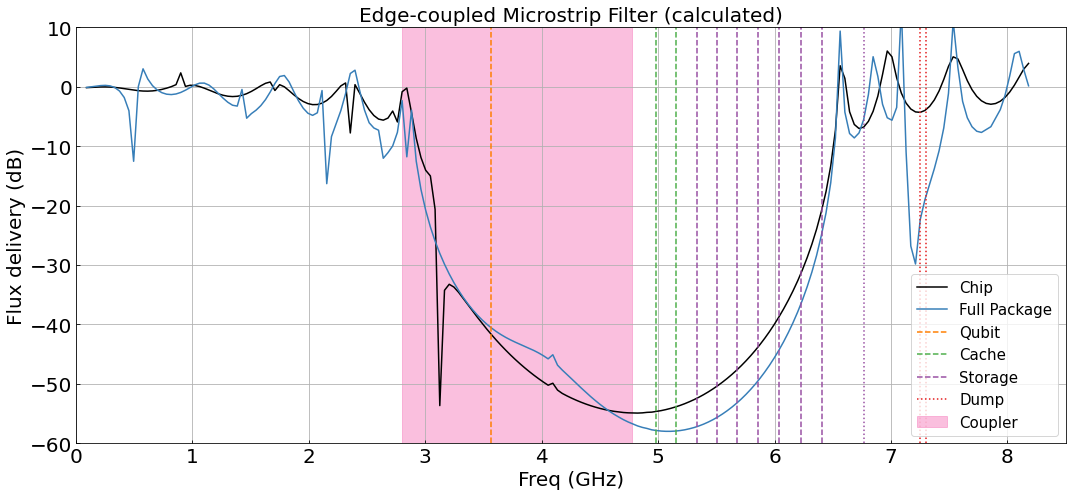

In [71]:
import matplotlib.transforms as mtransforms
fig, ax = plt.subplots(1, 1, figsize=(15,7))
trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)

color1 = "#000000"  # A shade of blue
color2 = "#377eb8"    # A shade of orange
color3 = "#ff7f00"    # A shade of orange
color4 = "#4daf4a"    # A shade of orange
color5 = "#984ea3"    # A shade of orange
color6 = "#e41a1c"    # A shade of orange
color7 = "#f781bf"    # A shade of orange


# plt.plot(f_list/1e9, S21, '-', color=color1, label='Analytic')
# plt.plot(freq2/1.1, 20*np.log10(SQUID_flux2)+20, '-', color='blue', label='Chip+Cavity')
plt.plot(freq2/1.1, 20*np.log10(SQUID_flux2)+20, '-', color=color1, label='Chip')
plt.plot(freq3/1.1, 20*np.log10(SQUID_flux3)+20, '-', color=color2, label='Full Package')
# plt.axvline(freq_low,  linestyle='--', color = 'r', label = 'Coupler low frequency')
# plt.axvline(freq_hi,  linestyle='--', color = 'b', label = 'Coupler high frequency')
# ax.axvspan(freq_low, freq_hi, alpha=0.5, color='red', label='coupler')
# ax.axvspan(cavity[0], cavity[1], alpha=0.5, color='green', label='M and S modes')
ax.axvline(3.568,  linestyle='--', color = color3, label = 'Qubit')
ax.axvline(4.984,  linestyle='--', color = color4, label = 'Cache')
ax.axvline(5.158,  linestyle='--', color = color4)
ax.axvline(5.333,  linestyle='--', color = color5, label = 'Storage')
ax.axvline(5.505,  linestyle='--', color = color5)
ax.axvline(5.681,  linestyle='--', color = color5)
ax.axvline(5.860,  linestyle='--', color = color5)
ax.axvline(6.037,  linestyle='--', color = color5)
ax.axvline(6.229,  linestyle='--', color = color5)
ax.axvline(6.407,  linestyle='--', color = color5)
ax.axvline(6.768,  linestyle=':', color = color5)
ax.axvline(7.297,  linestyle=':', color = color6, label = 'Dump')
ax.axvline(7.252,  linestyle=':', color = color6)
ax.axvspan(2.8, 4.78, alpha=0.5, color=color7, label='Coupler')
# ax.axhspan(-110, -88,  alpha=0.5, color = 'orange', label='Protected region')
# ax.axvspan(7.2, 7.5, alpha=0.5, color='red', label='Dump')
# ax.axvspan(7.2, 7.5, alpha=0.5, color='Purple', label='Coupler')

ax.set_xlabel(r'Freq (GHz)',size=20)
ax.set_ylabel('Flux delivery (dB)',size=20)
ax.tick_params(labelsize=20)
plt.rcParams['xtick.direction'] = 'in'  
plt.rcParams['ytick.direction'] = 'in'
plt.title(r'Edge-coupled Microstrip Filter (calculated)',size=20)
# plt.yscale('log')
plt.ylim([-60,10])
plt.xlim([0,8.5])
plt.grid()
plt.legend(fontsize=15, loc="lower right")
plt.tight_layout()
plt.savefig('Flux_filter.pdf')

In [7]:
file1 = "G:\\共享云端硬盘\\multimode\\Multimode\\HFSS simulation\\HFSS_output\\balun_output1.csv"
file2 = "G:\\共享云端硬盘\\multimode\\Multimode\\HFSS simulation\\HFSS_output\\balun_cavity_output1.csv"
file3 = "G:\\共享云端硬盘\\multimode\\Multimode\\HFSS simulation\\HFSS_output\\balun_cavity_package_output1.csv"

pic_file1 = "G:\\共享云端硬盘\\multimode\\Multimode\\HFSS simulation\\HFSS_output\\balun_with_filter1.png"
pic_file2 = "G:\\共享云端硬盘\\multimode\\Multimode\\HFSS simulation\\HFSS_output\\balun_cavity_picture1.png"
pic_file3 = "G:\\共享云端硬盘\\multimode\\Multimode\\HFSS simulation\\HFSS_output\\balun_cavity_package_picture2.png"

data1 = pd.read_csv(file1)
data2 = pd.read_csv(file2)
data3 = pd.read_csv(file3)

freq1 = np.array(data1['Freq [GHz]'])
freq2 = np.array(data2['Freq [GHz]'])
freq3 = np.array(data3['Freq [GHz]'])

SQUID_flux1 = np.array(data1['SQUID_flux_driven []'])
SQUID_flux2 = np.array(data2['SQUID_flux_driven []'])
SQUID_flux3 = np.array(data3['SQUID_flux_driven []'])

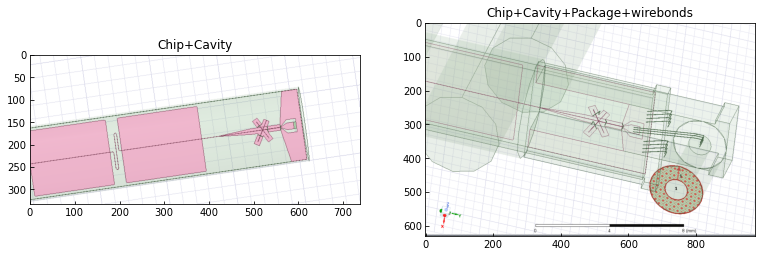

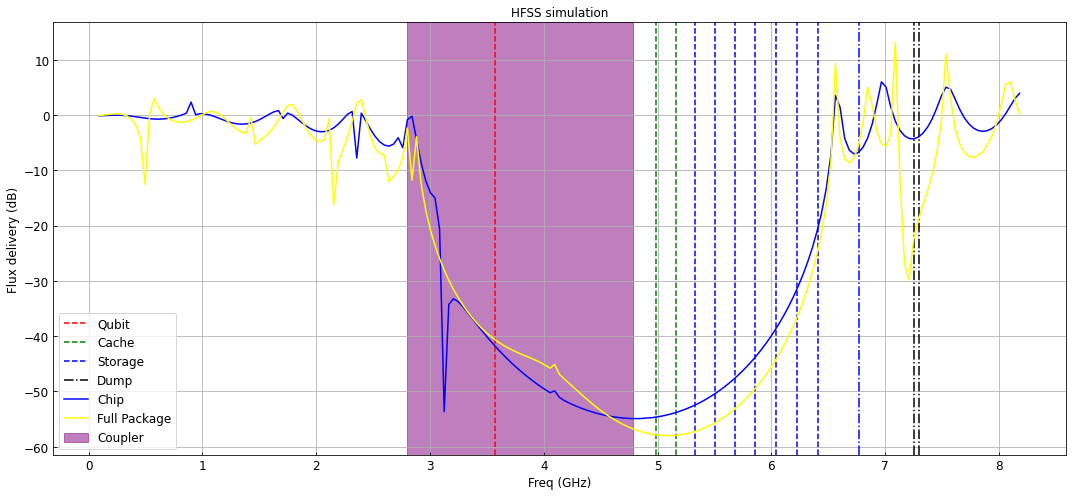

In [64]:
import matplotlib.transforms as mtransforms
from matplotlib.cbook import get_sample_data

fig = plt.figure(figsize=(13,8))
# ax1 = fig.add_subplot(1,2,1)
# im = plt.imread(get_sample_data(pic_file1))
# ax1.imshow(im)
# ax1.set_title(r'Chip')
ax2 = fig.add_subplot(1,2,1)
im = plt.imread(get_sample_data(pic_file2))
ax2.imshow(im)
ax2.set_title(r'Chip+Cavity')
ax3 = fig.add_subplot(1,2,2)
im = plt.imread(get_sample_data(pic_file3))
ax3.imshow(im)
ax3.set_title(r'Chip+Cavity+Package+wirebonds')


import matplotlib.transforms as mtransforms
fig, ax = plt.subplots(1, 1, figsize=(15,7))
trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
# plt.plot(freq1, 10*np.log10(SQUID_flux1)+10, '-', color='red', label='Chip')
ax.axvline(3.568,  linestyle='--', color = 'red', label = 'Qubit')
ax.axvline(4.984,  linestyle='--', color = 'green', label = 'Cache')
ax.axvline(5.158,  linestyle='--', color = 'green')
ax.axvline(5.333,  linestyle='--', color = 'blue', label = 'Storage')
ax.axvline(5.505,  linestyle='--', color = 'blue')
ax.axvline(5.681,  linestyle='--', color = 'blue')
ax.axvline(5.860,  linestyle='--', color = 'blue')
ax.axvline(6.037,  linestyle='--', color = 'blue')
ax.axvline(6.229,  linestyle='--', color = 'blue')
ax.axvline(6.407,  linestyle='--', color = 'blue')
ax.axvline(6.768,  linestyle='-.', color = 'blue')
ax.axvline(7.297,  linestyle='-.', color = 'black', label = 'Dump')
ax.axvline(7.252,  linestyle='-.', color = 'black')
ax.axvspan(2.8, 4.78, alpha=0.5, color='purple', label='Coupler')
# plt.plot(f_list/1e9, S21, '-', color='black')
plt.plot(freq2/1.1, 20*np.log10(SQUID_flux2)+20, '-', color='blue', label='Chip')
plt.plot(freq3/1.1, 20*np.log10(SQUID_flux3)+20, '-', color='yellow', label='Full Package')



# plt.imshow(im)

ax.set_xlabel(r'Freq (GHz)',size=12)
ax.set_ylabel(r'Flux delivery (dB)',size=12)
ax.tick_params(labelsize=12)
plt.rcParams['xtick.direction'] = 'in'  
plt.rcParams['ytick.direction'] = 'in'
plt.title(r'HFSS simulation',size=12)
# plt.yscale('log')
# plt.ylim([3000,14000])
plt.grid()
plt.legend(fontsize=12)
plt.tight_layout()

# play with different parameters

In [74]:

# h = 500*1e-6
# w_lo = 2.4225*1e-3
# s_lo = 15*1e-6
# length_lo = 5.5*1e-3
# w_hi = 10*1e-6
# s_hi = 15*1e-6
# length_hi = 5.5*1e-3


h = 500*1e-6

# Capcitor Pads
w_lo = 2.4225*1e-3 #* 10
s_lo = 15*1e-6
length_lo = 3*1e-3

# Inductor
w_hi = 10*1e-6 
s_hi = 15*1e-6
length_hi = 5.9*1e-3

er = 11.0
z0 = 50
zlo = Zco(er, w_lo, s_lo, h)
zhi = Zco(er, w_hi, s_hi, h)
erlo = ero(er, w_lo, w_lo, h)
erhi = ero(er, w_hi, w_hi, h)

# zhi = 138.45   # from online calculator
# zlo = 22.91

vlo = 3*10**8/np.sqrt(erlo)
vhi = 3*10**8/np.sqrt(erhi)

# vlo = 1.2*10**8
# vhi = 1.2*10**8

nstep = 1000
f_list = np.linspace(0.1*10**9, 9*10**9, nstep)
S21_new = []
for f in f_list:
    ABCDlo = ABCD_HL(zlo, f, length_lo, vlo)
    ABCDhi = ABCD_HL(zhi, f, length_hi, vhi)
    ABCD = ABCDlo*ABCDhi*ABCDlo*ABCDhi*ABCDlo*ABCDhi*ABCDlo*ABCDhi*ABCDlo
    ss = 2/(ABCD[0,0]+ABCD[0,1]/z0+ABCD[1,0]*z0+ABCD[1,1])
    S21_new.append(10*np.log10(abs(ss*ss)))

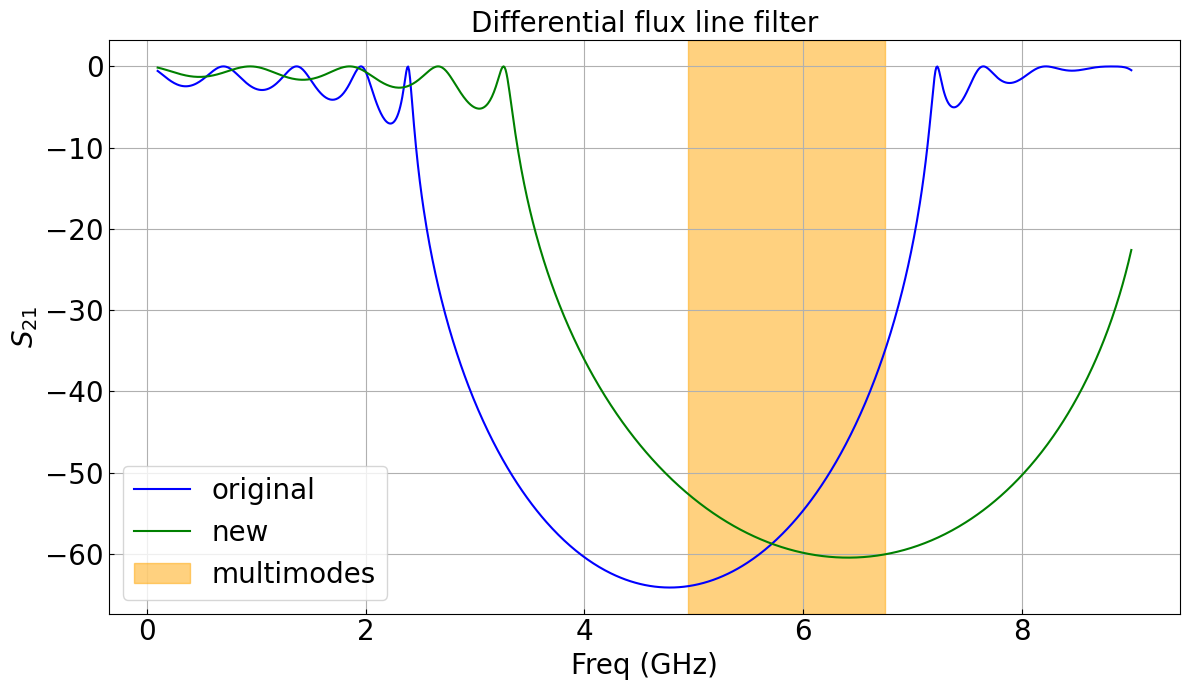

In [75]:
import matplotlib.transforms as mtransforms
fig, ax = plt.subplots(1, 1, figsize=(12,7))
trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
plt.plot(f_list/1e9, S21, '-', color='blue', label='original')
plt.plot(f_list/1e9, S21_new, '-', color='green', label='new')
ax.set_xlabel(r'Freq (GHz)',size=20)
ax.set_ylabel(r'$S_{21}$',size=20)
ax.tick_params(labelsize=20)
plt.rcParams['xtick.direction'] = 'in'  
plt.rcParams['ytick.direction'] = 'in'
plt.title(r'Differential flux line filter',size=20)

ax.axvspan(cavity[0], cavity[1], alpha=0.5, color='orange', label='multimodes')
# ax.axvspan(7.3, 7.5, alpha=0.5, color='red', label='bad')
# plt.yscale('log')
# plt.ylim([3000,14000])
plt.grid()
plt.legend(fontsize=20)
plt.tight_layout()

Effect of Tuning Parameters: 
1. Increasing high impedance length reduces attebnuation but moves band rightwards
2. Increasing low impedance length introduces more bands

In [12]:

h = 500*1e-6
w_lo = 2.55*1e-3*0.95
s_lo = 5*1e-6
length_lo = 5.5*1e-3
w_hi = 5*1e-6
s_hi = 5*1e-6
length_hi = 5.5*1e-3
er = 11.1
z0 = 50
zlo = Zco(er, w_lo, s_lo, h)
zhi = Zco(er, w_hi, s_hi, h)
erlo = ero(er, w_lo, w_lo, h)
erhi = ero(er, w_hi, w_hi, h)

# zhi = 138.45   # from online calculator
# zlo = 22.91

vlo = 3*10**8/np.sqrt(erlo)
vhi = 3*10**8/np.sqrt(erhi)

# vlo = 1.2*10**8
# vhi = 1.2*10**8

nstep = 1000
f_list = np.linspace(0.1*10**9, 9*10**9, nstep)
S21_new = []
for f in f_list:
    ABCDlo = ABCD_HL(zlo, f, length_lo, vlo)
    ABCDhi = ABCD_HL(zhi, f, length_hi, vhi)
    ABCD = ABCDhi*ABCDlo*ABCDhi*ABCDlo*ABCDhi*ABCDlo*ABCDhi*ABCDlo*ABCDhi*ABCDlo*ABCDhi
    ss = 2/(ABCD[0,0]+ABCD[0,1]/z0+ABCD[1,0]*z0+ABCD[1,1])
    S21_new.append(10*np.log10(abs(ss*ss)))

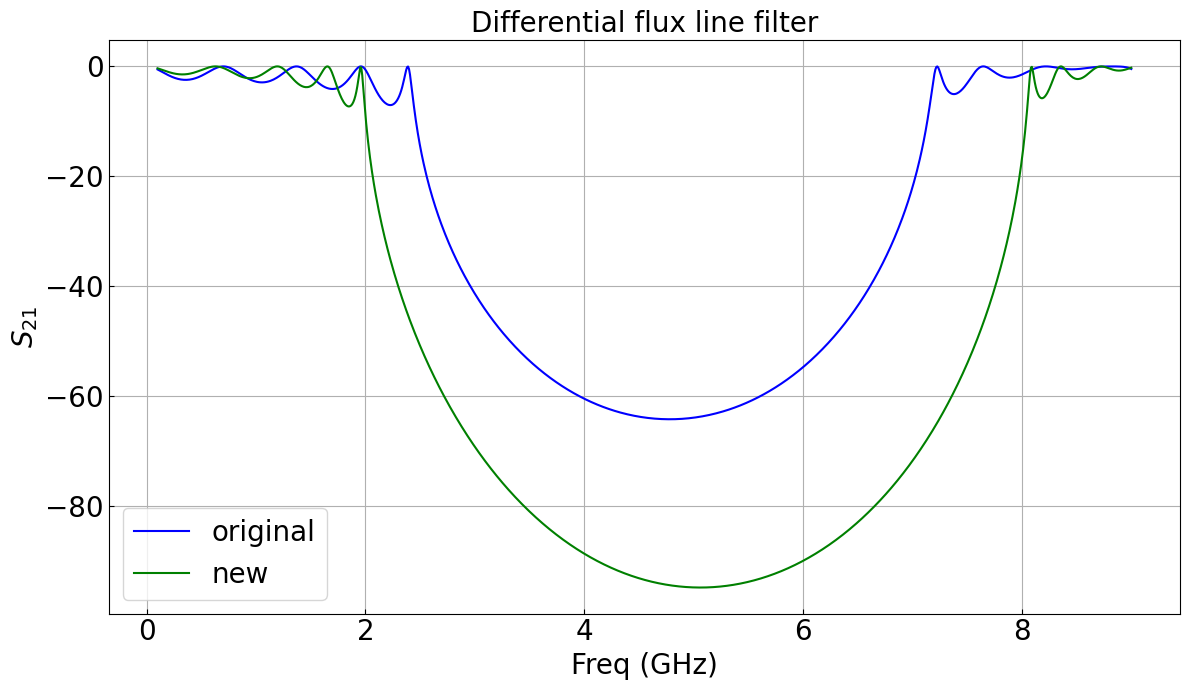

In [13]:
import matplotlib.transforms as mtransforms
fig, ax = plt.subplots(1, 1, figsize=(12,7))
trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
plt.plot(f_list/1e9, S21, '-', color='blue', label='original')
plt.plot(f_list/1e9, S21_new, '-', color='green', label='new')
ax.set_xlabel(r'Freq (GHz)',size=20)
ax.set_ylabel(r'$S_{21}$',size=20)
ax.tick_params(labelsize=20)
plt.rcParams['xtick.direction'] = 'in'  
plt.rcParams['ytick.direction'] = 'in'
plt.title(r'Differential flux line filter',size=20)
# plt.yscale('log')
# plt.ylim([3000,14000])
plt.grid()
plt.legend(fontsize=20)
plt.tight_layout()

In [9]:

h = 500*1e-6
w_lo = 5*1e-5
s_lo = 3*1e-6
length_lo = 4.8*1e-3
w_hi = 3*1e-6
s_hi = 3*1e-6
length_hi = 4.8*1e-3
er = 11.1
er_new = 3
z0 = 50
zlo = Zco(er, w_lo, s_lo, h)
zhi = Zco(er, w_hi, s_hi, h)
erlo = ero(er, w_lo, w_lo, h)
erhi = ero(er, w_hi, w_hi, h)

# zhi = 138.45   # from online calculator
# zlo = 22.91

vlo = 3*10**8/np.sqrt(erlo)
vhi = 3*10**8/np.sqrt(erhi)

# vlo = 1.2*10**8
# vhi = 1.2*10**8

nstep = 1000
f_list = np.linspace(0.01*10**9, 12*10**9, nstep)
S21_new = []
for f in f_list:
    ABCDlo = ABCD_HL(zlo, f, length_lo, vlo)
    ABCDhi = ABCD_HL(zhi, f, length_hi, vhi)
    ABCD = ABCDlo*ABCDhi*ABCDlo*ABCDhi*ABCDlo*ABCDhi*ABCDlo*ABCDhi*ABCDlo
    ss = 2/(ABCD[0,0]+ABCD[0,1]/z0+ABCD[1,0]*z0+ABCD[1,1])
    S21_new.append(10*np.log10(abs(ss*ss)))

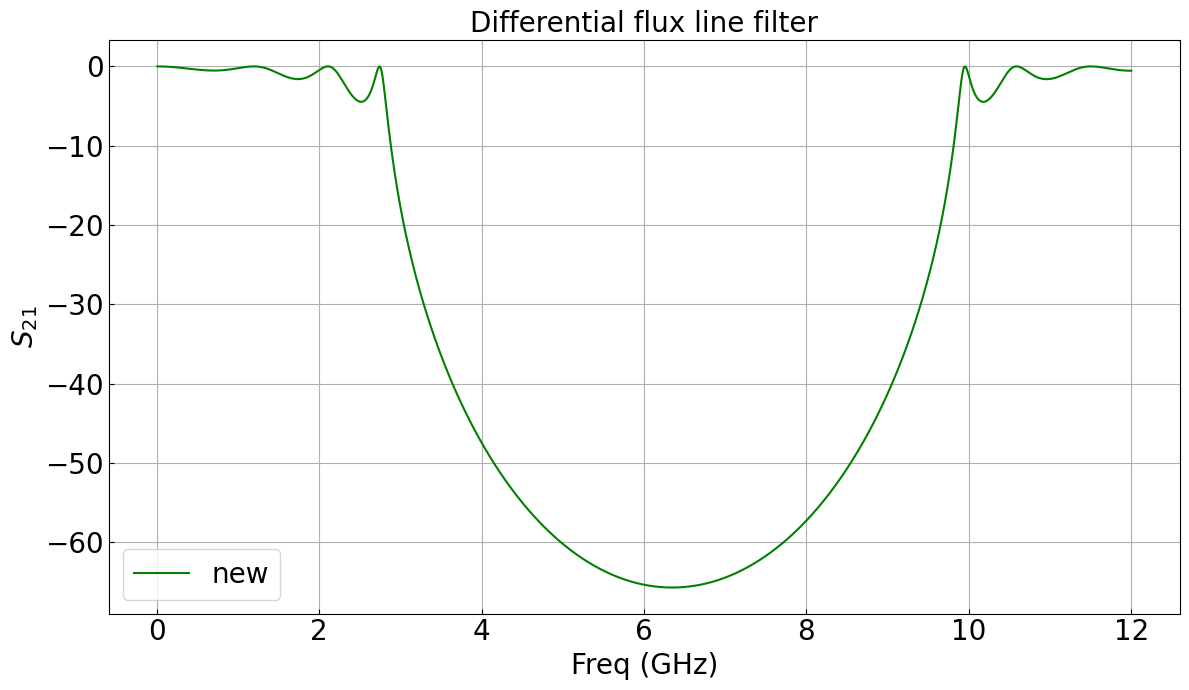

In [10]:
import matplotlib.transforms as mtransforms
fig, ax = plt.subplots(1, 1, figsize=(12,7))
trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
# plt.plot(f_list/1e9, S21, '-', color='blue', label='original')
plt.plot(f_list/1e9, S21_new, '-', color='green', label='new')
ax.set_xlabel(r'Freq (GHz)',size=20)
ax.set_ylabel(r'$S_{21}$',size=20)
ax.tick_params(labelsize=20)
plt.rcParams['xtick.direction'] = 'in'  
plt.rcParams['ytick.direction'] = 'in'
plt.title(r'Differential flux line filter',size=20)
# plt.yscale('log')
# plt.ylim([3000,14000])
plt.grid()
plt.legend(fontsize=20)
plt.tight_layout()
plt.show()